# Model Evaluation and Analysis

This notebook loads the trained Logistic Regression model and the test dataset to generate analysis figures (such as the confusion matrix and evaluation metrics) as required.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

from src.dataset import IrisDataset
from src.model import LogisticRegressionModel

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("../data/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


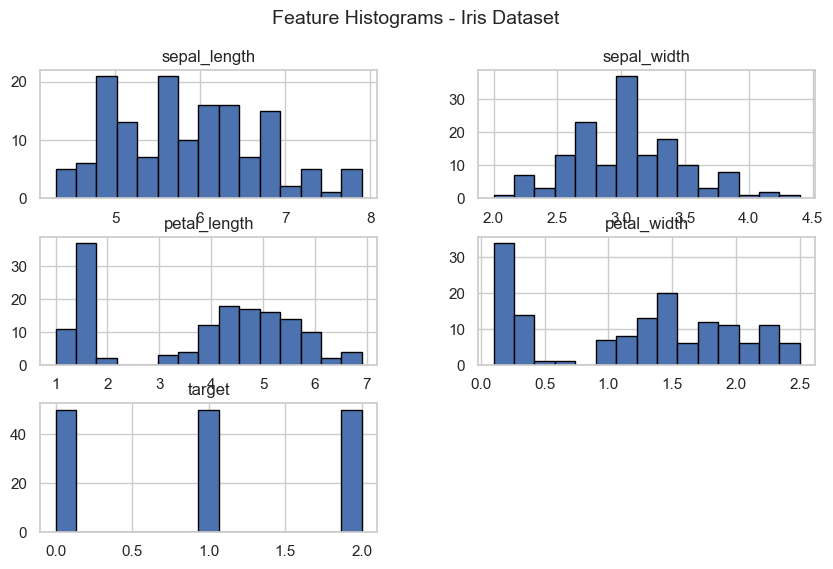

In [3]:
df.hist(figsize=(10, 6), bins=15, edgecolor='black')
plt.suptitle("Feature Histograms - Iris Dataset", fontsize=14)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
sns.pairplot(df, hue="target", palette="Set2")
plt.show()

In [ ]:
dataset = IrisDataset(test_size=0.25, random_state=42)
X_train, X_test, y_train, y_test = dataset.get_data("../data/iris.csv")

model = LogisticRegressionModel()
model.load("../models/model.joblib")

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - Iris Dataset")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()